# Simple model

We simulate bursts with N=1 component and infer one parameter, the peak time (`t0`) with MCMC and normalizing flows.

In [34]:
import sys
sys.path.append('..')

import emcee
import numpy as np
import math 
import matplotlib.pyplot as plt

from src.helpers import twoexp, combined_twoexp, simulate_burst, plot_simulated_burst

In [2]:
time = np.linspace(0, 1.0, 1000)
N = 1
amp = 20.0
t0 = 0.4
rise = 0.03
skew = 5.0

ybkg = 5.0

x_model, x_counts = simulate_burst(
    time=time,
    ncomp=N,
    burstparams=[t0, amp, rise, skew],
    ybkg=ybkg,
    return_model=True
)

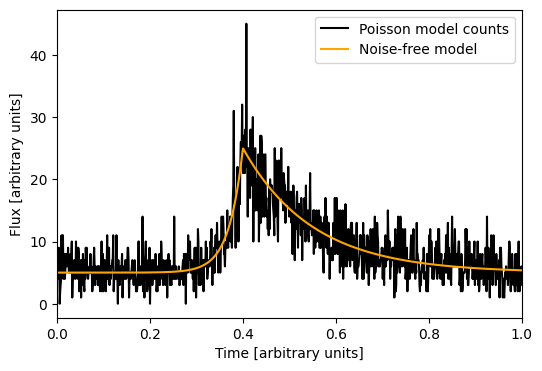

In [4]:
plot_simulated_burst(time, x_counts, x_model)

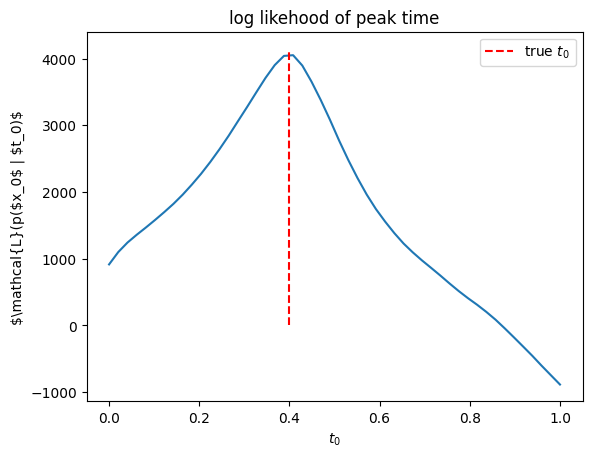

In [73]:
# define prior for peak time
def peaktime_prior(t0):
    """
    U(0,1), uniform pdf between 0 and 1
    """
    return np.random.uniform(0, 1)

def log_likelihood(t0, x_counts):
    """
    $ln(p(x_{counts} | t0)$
    natural logarithm of poisson likelihood.
    """
    
    L = 0
    # true rate 
    model_counts = combined_twoexp(time, [t0], [amp], [rise], [skew], ybkg)

    L = (
        -1 * np.sum(np.log(model_counts)) 
        + np.sum(x_counts * np.log(model_counts)) 
        - np.sum([math.log(math.factorial(x)) for x in x_counts])
    )
    
    return L


true_t0 = t0
t0s = np.linspace(0, 1, 50)

plt.plot(t0s, [log_likelihood(t0, x_counts) for t0 in t0s])
plt.title("log likehood of peak time")
plt.ylabel("$\mathcal{L}(p($x_0$ | $t_0)$")
plt.xlabel("$t_0$")
plt.vlines([true_t0],  ymin=0, ymax=max([log_likelihood(t0, x_counts) for t0 in t0s]) +100, linestyles="dashed", color ='red', label='true $t_0$')
plt.legend()
plt.show()


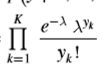

In [92]:
nwalkers = 20
ndim = 1
p0 = np.random.rand(nwalkers, ndim) # initial position of the walkers

def log_prob(t0, *args):
    
    # t0 is bounded by the uniform prior
    if t0 < 0 or t0 > 1:
        return -np.inf
    
    # otherwise its equal to the likelihood
    return log_likelihood(t0, *args)

# https://emcee.readthedocs.io/en/stable/tutorials/quickstart/
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=[x_counts])

In [93]:
# burn-in of 100 steps
state = sampler.run_mcmc(p0, 100)
sampler.reset()

In [94]:
sampler.run_mcmc(state, 1000)

State([[0.39640695]
 [0.39836872]
 [0.39761755]
 [0.39964308]
 [0.3979394 ]
 [0.39934391]
 [0.39931541]
 [0.40014659]
 [0.39912617]
 [0.39988467]
 [0.40038763]
 [0.39812397]
 [0.40037227]
 [0.3970715 ]
 [0.4008595 ]
 [0.39763212]
 [0.39740769]
 [0.3976458 ]
 [0.39808847]
 [0.39953742]], log_prob=[4067.01087577 4068.98362635 4068.39335248 4068.94329637 4068.626976
 4069.04935955 4069.04446178 4068.75730478 4069.01779302 4068.84493318
 4068.69414716 4068.77399373 4068.69767366 4067.81263555 4068.32556732
 4068.40330276 4068.25659594 4068.41270432 4068.74498134 4068.99160905], blobs=None, random_state=('MT19937', array([2418299743, 3475665088, 2932732993,  309090066, 3103045511,
        753797974,  548366153,  709812226, 2850678853, 2143376236,
       1907499152, 3730124422, 3561241338, 1516172504, 1857107635,
        211713618,  932477169, 3324675987, 3597521938, 1838277565,
        654976303, 3410569259, 2109192882, 2087531271, 2888314103,
       2453991291, 1805270123, 1586366636, 3805

[0.40494503]


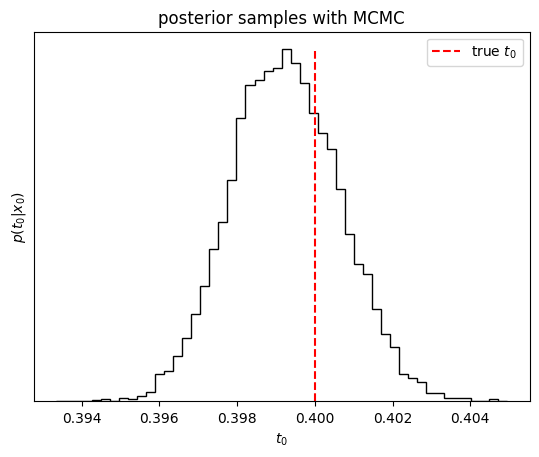

In [97]:
samples = sampler.get_chain(flat=True)
print(max(samples))
plt.title("posterior samples with MCMC")
frequencies, _, _ = plt.hist(samples[:, 0], 50, color="k", histtype="step")
plt.xlabel("$t_0$")
plt.ylabel("$p(t_0 | x_0)$")
plt.gca().set_yticks([])
plt.vlines([true_t0],  ymin=0, ymax=max(frequencies), linestyles="dashed", color ='red', label='true $t_0$')
plt.legend()
plt.show()

In [84]:
print(
    "Mean acceptance fraction: {0:.3f}".format(
        np.mean(sampler.acceptance_fraction)
    )
)

Mean acceptance fraction: 0.795


In [ ]:
# Normalizing flow

# generate bunch of training data (all params fixed except t0?)

# generate posterior using normalizing flow ?